In [1]:
from mpi4py import MPI
from matplotlib import pyplot as plt
import coqui

# Create CoQui MPI handler and set logging verbosity in the beginning
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-11 16:30:08.077336


# GW Approximation

<figure style="text-align: center;">
 <img src="../../images/gw_pentagon.png" alt="GW pentagon" width="30%">
 <img src="../../images/gw_flavors_bandgaps.png" alt="GW band-gap comparison" width="36%">
 <figcaption><em>Figure 1:</em> (Left) GW self-consistent equations. (Right) Typical band-gap trends from DFT and GW at different levels of self-consistency.</figcaption>
</figure>

In this notebook, we focus on the GW approximation, a widely used many-body perturbation theory (MBPT) for excited-state properties of weakly correlated materials.

Density functional theory (DFT), despite being a workhorse in materials simulation, is formally a ground-state theory and does not rigorously describe excitation properties. A well-known consequence is the systematic underestimation of band gaps in semiconductors and insulators, as illustrated in the right panel of Figure 1. In contrast, the GW approximation is a Green's function-based MBPT that yields physical quasiparticle excitations with direct correspondence to experimental spectroscopies. This makes GW a practical and reliable method for predicting excited-state properties, particularly in weakly to moderately correlated systems.

> Note: GW is still limited by its perturbative nature based on the random phase approximation (RPA). Combinations with higher-level theories are sometimes necessary for more accurate predictions, such as the Bethe-Salpeter equation (BSE) for excitonic effects and dynamical mean-field theory (DMFT) for strong local correlations.

As shown in the left panel of Figure 1, the GW approximation corresponds to the lowest-order approximation to the vertex function $\Gamma^{GW}(1,2;3)=\delta(1,2)\delta(1,3)$ in Hedin's equations, resulting in simplified expressions for the irreducible polarizability and self-energy:
$$
\Pi^{GW}(1,2)=-G(1,2)G(2,1),\quad \Sigma^{GW}(1,2)=G(1,2)W(1,2).
$$
and
$$
W(1,2)=V(1,2)+V(1,3)\Pi^{GW}(3,4)W(4,2),\quad G(1,2)=G_0(1,2)+G_0(1,3)\Sigma^{GW}(3,4) G(4,2).
$$
Here, `1`, `2`, etc. are space-time coordinates, and repeated arguments are summed or integrated over.

Despite their compact appearance, these simplified equations remain numerically demanding because of self-consistency and the frequency dependence of $W$ and $\Sigma$. In practical GW implementations, several additional approximations are often introduced to make the calculation affordable. Common examples include:
- **Single-shot $G_0W_0$**: evaluate $\Sigma$ once from a fixed starting Green's function $G_0$ (typically DFT).

- **Quasiparticle approximation**: evaluate quasiparticle energies near pole positions instead of carrying the full frequency dependence of self-energy.

- **Partial self-consistency** (for example, evGW or qsGW): update selected quantities iteratively rather than solving the full frequency-dependent problem at every step.

- **Model treatments of the frequency dependence of $W$**: replace the full dynamical structure of the screened interaction with simplified models, such as plasmon-pole approximations, to reduce cost.

In CoQuí, the numerical challenges of GW are addressed instead through two compression ideas: compact imaginary-axis representations and compressed Coulomb Hamiltonians in a discrete single-particle basis. These ideas make fully frequency-dependent GW calculations substantially more practical, and they also make simplified GW flavors such as quasiparticle self-consistent schemes more efficient when those approximations are still desirable.

**What's covered in this notebook**

1. How to construct a Coulomb Hamiltonian for many-body electronic structure calculations.

2. How to run GW with different levels of self-consistency.

3. How to visualize GW band structures and spectral functions.

First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `si_555/` (QE and Wannier90 outputs for 5x5x5 Silicon)


In [2]:
%%bash
python copy_notebook_inputs.py

Removed directory: si_555
Copied: data/qe_inputs/si/555/out -> si_555/out
Copied: data/qe_inputs/si/555/mlwf/si.win -> si_555/mlwf/si.win
Copied: data/qe_inputs/si/555/mlwf/si.mlwf.h5 -> si_555/mlwf/si.mlwf.h5
Notebook inputs are ready.


### Section 1: Build the Coulomb Hamiltonian for GW

<figure style="text-align: center;">
 <img src="../../images/coqui_problem_setup.png" alt="Problem setup in CoQuí" width="60%">
 <figcaption><em>Figure 1:</em> Problem setup for a many-body simulation.</figcaption>
</figure>

Many-body calculations in CoQui rely on a second quantized Hamiltonian, consisting of a non-interacting part and a Coulomb interaction part. The non-interacting Hamiltonian, as we have seen in the previous notebook, is defined by the `Mf` object. 

In this section, we will be working on construction of the Coulomb Hamiltonian: 
$$
\hat{H}_{\mathrm{int}} = \frac{1}{2}\sum _{ijkl}V^{\textbf{k}_1\textbf{k}_2\textbf{k}_3\textbf{k}_4} _{ijkl} c^{\textbf{k}_1\dagger} _{i} c^{\textbf{k}_3\dagger} _{k} c^{\textbf{k}_4} _{l} c^{\textbf{k}_2} _{j}
$$
where the Coulomb matrix elements are defined as:
$$
V^{\textbf{k}_1\textbf{k}_2\textbf{k}_3\textbf{k}_4} _{ijkl} = \int d\textbf{r} \int d\textbf{r}' \phi^{\textbf{k}_1*} _{i} (\textbf{r})\phi^{\textbf{k}_2} _{j}(\textbf{r})\frac{1}{|\textbf{r}-\textbf{r}'|}\phi^{\textbf{k}_3*} _{k}(\textbf{r}')\phi^{\textbf{k}_4} _{l}(\textbf{r}')
$$
This is the most general form of Coulomb Hamiltonian, capturing both *local* and *non-local* interactions among *all* single-particle states. Here, the momentum transferred between a pair of single-particle states 
$\rho^{\textbf{k}_{1}\textbf{k}_{2}}_{ij}(\textbf{r}) = \phi^{\textbf{k}_{1}*}_{i}(\textbf{r})\phi^{\textbf{k}_{2}}_{j}(\textbf{r})$
(also known as the pair densities) satisfies momentum conservation: 

$$
\textbf{k}_1 - \textbf{k}_2 + \textbf{G} = \textbf{k}_3 - \textbf{k}_4,
$$

where $\textbf{G}$ represents a reciprocal lattice vector of the system.

#### 🔹 THC Coulomb construction

In CoQui, the Coulomb interaction is handled by the `ThcCoulomb` class, in which the Coulomb matrix elements are represented in tensor hypercontraction (THC) form by exploiting the low-rank structure of the Coulomb tensor.

$$
V^{\mathbf{k}_1\mathbf{k}_2\mathbf{k}_3\mathbf{k}_4}_{ijkl}
\approx \sum_{\mu\nu}^{N_\mu} X^{\mathbf{k}_1*}_{\mu i} X^{\mathbf{k}_2}_{\mu j} V^{\mathbf{q}}_{\mu\nu} X^{\mathbf{k}_3*}_{\nu k} X^{\mathbf{k}_4}_{\nu l}.
$$

Here, $\mathbf{q} = \mathbf{k}_{1} - \mathbf{k}_{2}$, and the Greek letters $\mu$ and $\nu$ label THC auxiliary basis functions.

A `ThcCoulomb` object is constructed through:

> ```python
> coqui.make_thc_coulomb(mf: Mf, params: dict) -> ThcCoulomb
> ```

Function inputs:
- `mf`: the `Mf` object containing the single-particle basis information.

- `params`: a dictionary of parameters controlling the THC construction. Key parameters include:
    - `thresh` (default: 1e-5): THC threshold controlling the size of the THC auxiliary basis.

    - `ecut` (default: 0.4 * Mf.ecutrho()): plane-wave cutoff (Hartree).

    - `save` (default: ""): HDF5 file to save the THC Coulomb matrix elements (`""` means no saving).

> Tip: The resulting `ThcCoulomb` object can be constructed once and reused for multiple many-body calculations.

> Tip: For complete parameter documentation, use `help(coqui.make_thc_coulomb)` in Python.

#### 🔹 Example
In the following example, a `Mf` object for 5x5x5 Silicon is built using a pre-computed QE output, and then a THC Coulomb Hamiltonian is constructed. 

In [ ]:
# Step 1: Build mean-field object
mf_params = {
    "prefix": "si",
    "outdir": "si_555",
    "nbnd": 20,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Step 2: Build THC Coulomb Hamiltonian
thc_params = {
    "thresh": 1e-3,
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

Questions:
1. How many THC auxiliary basis (i.e., interpolation points) are used to compress the Coulomb Hamiltonian?

2. Play with the `thresh` parameter. As you tighten the threshold, the number of THC auxiliary basis functions should increase, leading to a more accurate representation of the Coulomb Hamiltonian. 

#### 🔹 Hands-on — Save and reload the THC Hamiltonian

Goal: Storing the Coulomb Hamiltonian to disk to avoid recomputation.

Steps:
1. Add a `save` h5 file name to `thc_params` (e.g., `"save": "thc.coulomb.h5"`).

2. Build `ThcCoulomb` and confirm data are written to HDF5.

3. Rebuild with the same parameters and confirm from the log output that a pre-computed Coulomb Hamiltonian is loaded from the file, instead of repeating the full construction.


In [ ]:
# Step 1: Save the THC Hamiltonian
thc_params["save"] = "thc.coulomb.h5"
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# Step 2: Reload from the same file
thc_reloaded = coqui.make_thc_coulomb(mf=mf, params=thc_params)

### Section 2: GW approximation

<figure style="text-align: center;">
 <img src="../../images/coqui_simulation_gw.png" alt="GW simulation in CoQuí" width="60%">
 <figcaption><em>Figure 2:</em> GW Dyson-SCF simulation stage.</figcaption>
</figure>

With an interacting Hamiltonian in hand, we are ready to run a GW simulation.

In CoQuí, GW equations (or more broadly, Green's function methods) are implemented based on two compression ideas: 

- Discrete Lehmann representation (DLR) for imaginary-axis correlation functions and Fourier transforms, and

- THC factorization for Coulomb matrix elements in single-particle orbital space.

As introduced in this [paper](https://pubs.acs.org/doi/10.1021/acs.jctc.4c00085), the evaluations of the irreducible polarizability and self-energy therefore acquire simple forms:

$$

\Pi^{\mathbf{q}}_{\mu\nu}(\tau)= \sum_{\mathbf{k}}-G^{\mathbf{k+q}}_{\mu\nu}(\tau)G^{\mathbf{k}}_{\nu\mu}(-\tau),\qquad \Sigma^{\mathbf{k}}_{\mu\nu}(\tau)=\sum_{\mathbf{q}}G^{\mathbf{k+q}}_{\mu\nu}(\tau)W^{\mathbf{q}}_{\nu\mu}(\tau),

$$
with the Dyson equations of $G$ and $W$ that couple $G$, $\Pi$, $W$, and $\Sigma$ self-consistently.

Such a reformulation for the GW equations leads to a significant reduction in computational cost compared to conventional quartic-scaling implementations based on the Adler-Wiser polarizability. Formally, the THC reformulation leads to cubic scaling with system size and linear scaling with respect to the number of k-points. All equations also scale linearly with respect to the number of imaginary time and frequency points.

> Note: The evaluations of $\Pi$ and $\Sigma$ in the THC formulation resemble the GW space-time algorithm if the THC indices are replaced by a real-space grid. Since the THC basis is much more compact than the real-space grid, the THC formulation is formally more efficient than the space-time algorithm.

In the rest of this notebook, we will use these ideas in two complementary GW workflows. First, we will study eigenvalue self-consistent GW (evGW), which focuses on quasiparticle energies and is convenient for band-structure analysis. Then we will turn to full-frequency self-consistent GW (scGW), which retains the full dynamical structure of the Green's function and enables spectral analysis beyond simple quasiparticle peaks.

#### 🔹 Internal modularization of GW calculations in CoQui

<figure style="text-align: center;">
 <img src="../../images/gw_pentagon_with_coqui_module.png" alt="GW workflow modules in CoQuí" width="40%">
 <figcaption><em>Figure 3:</em> Conceptual workload division of GW in CoQuí.</figcaption>
</figure>

In CoQuí, GW calculations are internally organized into several modules, as shown in Figure 3. Although this modularization is not exposed directly through the user API, the log output of a GW run closely follows the same structure. Understanding this layout helps users interpret the runtime messages, identify where time is spent, and recognize which stage is responsible if a calculation becomes slow or unstable.

- **Screened Coulomb interaction module**: build the screened interaction $W$ together with the irreducible polarizability $\Pi$.

- **Self-energy modules**: 
    - **Hartree-Fock (HF) solver**: evaluate the static part of $\Sigma$.
    
    - **GW solver**: evaluate the dynamic part of $\Sigma$ from the current $G$ and $W$.

- **SCF module**: 
    - **QP-SCF**: perform quasiparticle self-consistency loops.

    - **Dyson-SCF**: perform self-consistency loops with full frequency depenence of $G$ and $\Sigma$.

#### 🔹 Eigenvalue self-consistent GW approximation

The eigenvalue self-consistent GW (evGW) approximation updates quasiparticle energies while keeping the quasiparticle wavefunctions fixed to the Kohn-Sham (KS) orbitals. In this approximation, only the diagonal matrix elements of $\Sigma(\omega)$ are sampled at the quasiparticle energies, and those values are used to update the energy levels iteratively.

This leads to a quasiparticle equation of the form

$$
\epsilon^{\mathrm{QP}}_{i\mathbf{k}} = \epsilon^{\mathrm{KS}}_{i\mathbf{k}} + \langle \phi^{\mathrm{KS}}_{i\mathbf{k}} | \Sigma(\epsilon^{\mathrm{QP}}_{i\mathbf{k}}) - V_{\mathrm{xc}} | \phi^{\mathrm{KS}}_{i\mathbf{k}} \rangle,
$$

where off-diagonal self-energy matrix elements are neglected. The updated quasiparticle energies are then used to construct the Green's function

$$
G^{\mathbf{k}}(i\omega_{n}) = \sum_{i} \frac{|\phi^{\mathrm{KS}}_{i\mathbf{k}}\rangle \langle \phi^{\mathrm{KS}}_{i\mathbf{k}}|}{i\omega_{n} + \mu - \epsilon^{\mathrm{QP}}_{i\mathbf{k}}},
$$

for the next iteration until the quasiparticle energies are converged.

In CoQui, a self-consistent evGW calculation can be performed via a single function call:

>```python
>coqui.run_evgw(h_int: ThcCoulomb, params: dict)
>```

Function inputs:
- `h_int`: `ThcCoulomb` instance for Coulomb Hamiltonian.

- `params`: dictionary of GW parameters. Important parameters include:

    - `outdir` (default: `./`): output directory.

    - `prefix` (required): prefix (`{output}.mbpt.h5`).

    - `niter` (default: 1): number of self-consistent iterations.

    - `beta` (default: 1000): inverse temperature ($a.u.^{-1}$).

    - `iaft_prec` (default: `"medium"`): precision level (`"low"`, `"medium"`, `"high"`).

    For complete parameter options, use `help(coqui.run_evgw)`.

Output: 
- `{outdir}/{prefix}.mbpt.h5`: HDF5 checkpoint file containing quasiparticle energies and wavefunctions. This file can be used for post-processing, such as visualizing band structures, or as a checkpoint for restarting calculations. 

#### 🔹 Example

In the following example, we run a self-consistent evGW calculation for 5x5x5 Silicon at inverse temperature $\beta = 1000$ a.u.$^{-1}$. 

In [3]:
# Step 1: Build mean-field object
mf_params = {
    "prefix": "si",
    "outdir": "si_555/out",
    "nbnd": 20,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Step 2: Build THC Coulomb Hamiltonian
thc_params = {
    "thresh": 1e-3,
    "save": "thc.coulomb.h5"
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# Step 3: Run evGW calculation
gw_params = {
    "outdir": "./",
    "output": "si.evgw",
    "niter": 6,
    "beta": 1000, 
    "iaft": {"prec": "low"}
}
coqui.run_evgw(params=gw_params, h_int=thc)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 20
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 19 in the IBZ
  Number of electrons            = 8.0
  Electron density energy cutoff = 200.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 29.996 a.u. | FFT mesh = (17,17,17), Number of PWs = 2109


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = true
  --> Reading the precomputed THC integrals from file: thc.coulomb.h5


  Summary of THC Coulomb Integrals
  --------------------------------
  Number of interpolating points = 258
  X orbital index range          = [0,20)
  Y orbital index range          = [0

801013 a.u.
  total energy:                   1.3349884937040526 a.u.
 
energy difference:                0.0022666840098228835 a.u.
abs max diff of QP Hamiltonian:    0.0007729813242289829 a.u.


** Iteration # 6 **

╔═╗╔═╗╔═╗ ╦ ╦╦  ┌┬┐┬ ┬┌─┐ ┬ ┬┌─┐
║  ║ ║║═╬╗║ ║║   │ ├─┤│───├─┤├┤ 
╚═╝╚═╝╚═╝╚╚═╝╩   ┴ ┴ ┴└─┘ ┴ ┴└  

  Hartree, Exchange             = true, true
  Number of spins               = 1
  Number of polarizations       = 1
  Number of bands               = 20
  Number of THC auxiliary basis = 258
  K-points                      = 125 total, 19 in the IBZ
  Divergent treatment at q->0   = gygi

  Treatment of long-wavelength divergence in the non-local HF exchange potential : gygi

╔═╗╔═╗╔═╗ ╦ ╦╦  ┌─┐┌─┐┬─┐┌─┐┌─┐┌┐┌┌─┐┌┬┐  ┌─┐┌─┐┬ ┬┬  ┌─┐┌┬���┌┐ 
║  ║ ║║═╬╗║ ║║  └─┐│  ├┬┘├┤ ├┤ │││├┤  ││  │  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩  └─┘└─┘┴└─└─┘└─┘┘└┘└─┘─┴┘  └─┘└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Screening type                = rpa
  Number of bands               = 20
  Number of THC auxiliary basis 

#### 🔹 Post-processing: GW band structure along high-symmetry k-path

The quasiparticle solutions obtained from `run_evgw` routine live on the uniform k-mesh defined in the input `Mf` object, which often samples the Brillouin zone with coarse resolution due to the high computational cost in GW. 

Similar to how we obtained the DFT band structure via Wannier interpolation in the previous [notebook](../01_mf_and_mlwf/01_from_dft_to_coqui.ipynb), the same trick can be used to obtain the GW band structure using the same function `coqui.post_proc.band_interpolation` and `coqui.post_proc.plot_utils.band_plot` for visualization.

> Tip: The CoQui checkpoint file stores the solutions of *every* iteration during the self-consistency loop. Post-processing can therefore be performed separately for different stages of self-consistency loop by specifying the `iteration` parameter. This would allow users to track the evolution of the band structure during the GW iterations.

> Tip: The DFT results are also stored in the same checkpoint file as the zeroth iteration, allowing a convenient comparison of the DFT and GW band structures.

#### 🔹 Example

In the following example, we will interpolate the GW band structure along high-symmetry k-path at the *first* and the *final* iteration of evGW by specifying the `iteration` parameter. In addition, comparison with the DFT band structure is also shown to highlight the GW correction to the band structure. 

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 20
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 19 in the IBZ
  Number of electrons            = 8.0
  Electron density energy cutoff = 200.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 29.996 a.u. | FFT mesh = (17,17,17), Number of PWs = 2109

╔═╗┌─┐╔═╗ ┬ ┬┬  ╦ ╦┌─┐┌┐┌┌┐┌┬┌─┐┬─┐  ╦┌┐┌┌┬┐┌─┐┬─┐┌─┐
║  │ │║═╬╗│ ││  ║║║├─┤│││││││├┤ ├┬┘  ║│││ │ ├┤ ├┬┘├─┘
╚═╝└─┘╚═╝╚└─┘┴  ╚╩╝┴ ┴┘└┘┘└┘┴└─┘┴└─  ╩┘└┘ ┴ └─┘┴└─┴o 

  Type                                  = quasiparticle
  Projection matrices                   = si_555/mlwf/si.mlwf.h5
  Input electronic structure:
    - Coqui h5                          = .//si.evgw.mbpt.h5
    - Data group                        = scf
    - Iteration                         = 6
  Input k-mesh:
    - Monkhorst-Pack mesh               =  (5,5

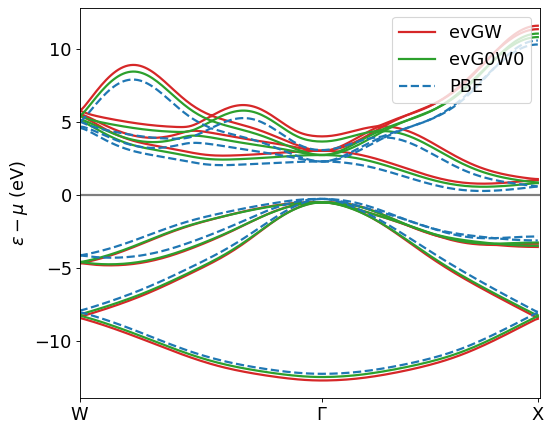

In [4]:
mf_params = {
    "prefix": "si",
    "outdir": "si_555/out",
    "nbnd": 20,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# By default, Wannier interpolation is performed for the last iteration in the checkpoint file, which corresponds to the final evGW solution.
winter_params = {
    "outdir": "./",
    "prefix": "si.evgw",
    "wannier_file": "si_555/mlwf/si.mlwf.h5", 
    "kpath": """
      W 0.50 0.25 0.75
      G 0.00 0.00 0.00
      X 0.50 0.00 0.50
    """,
}
coqui.post_proc.band_interpolation(mf, winter_params)

# evGW from the first iteration
winter_params["iteration"] = 1
coqui.post_proc.band_interpolation(mf, winter_params)

# PBE results from the zero-th iteration
winter_params["iteration"] = 0
coqui.post_proc.band_interpolation(mf, winter_params)

# -- Plotting --
fig, ax = plt.subplots(1, figsize=(7,5.5), dpi=80)

# By default, band_plot will plot the last iteration in the checkpoint file. 
coqui.post_proc.plot_utils.band_plot(
    ax, "si.evgw.mbpt.h5", 
    color='tab:red', linestyle="-", linewidth=2.0, label='evGW', fontsize=16
)
coqui.post_proc.plot_utils.band_plot(
    ax, "si.evgw.mbpt.h5", iteration=1,
    color='tab:green', linestyle="-", linewidth=2.0, label='evG0W0', fontsize=16
)
coqui.post_proc.plot_utils.band_plot(
    ax, "si.evgw.mbpt.h5", iteration=0,
    color='tab:blue', linestyle="--", linewidth=2.0, label='PBE', fontsize=16
)
ax.axhline(y=0, color = 'black', linestyle = '-', linewidth=2.0, alpha=0.5)
ax.legend(loc=1, fontsize=16)
plt.tight_layout()

#### 🔹 Full-frequency GW approximation

Apart from the quasiparticle approximation in the previous section, CoQui also supports full-frequency GW calculations, where the self-energy is evaluated on a discrete imaginary-frequency grid without replacing it by values only at quasiparticle poles. 

$$
G^{\mathbf{k}}(i\omega_{n}) = \left[i\omega_{n} + \mu - H^{\mathbf{k}}_{0} - \Sigma^{\mathbf{k}}(i\omega_{n})\right]^{-1},
$$

This allows for spetral properties beyond the quasiparticle picture, such as lifetime broadening and satellite features enabled by dynamic electron correlations. 

In weakly correlated materials, quasiparticle features are often dominant in spectra, making the quasiparticle approximation a highly efficient choice for first-principles simulations. In systems with strong correlations, such as transition metal oxides, the full frequency dependence of the self-energy can lead to significant renormalization of quasiparticle energies and the emergence of satellite features in the spectral function. In such cases, retaining the full frequency dependence becomes even more important.

In CoQui, the full-frequency GW calculation can be performed by a single function call with a very similar input structure as in the quasiparticle case:

> ```python
> coqui.run_gw(params: dict, h_int: coqui.ThcCoulomb)
> ```

Function inputs:
- `params`: dictionary of GW parameters. Key parameters include:

    - `outdir` (default: `./`): output directory.
    
    - `prefix` (required): output prefix (`{output}.mbpt.h5`).
    
    - `niter` (default: 1): Dyson-SCF iterations.
    
    - `beta` (default: 1000): inverse temperature ($a.u.^{-1}$).
    
    - `iaft_prec` (default: `"medium"`): precision level (`"low"`, `"medium"`, `"high"`).

- `h_int`: `ThcCoulomb` instance for Coulomb Hamiltonian.

For complete parameter options, use `help(coqui.run_gw)`.

Outputs:
- `{outdir}/{prefix}.mbpt.h5`: HDF5 checkpoint file containing the Green's function and self-energy on the imaginary-frequency grid. This file can be used for post-processing, such as analytic continuation to obtain spectral functions, or as a checkpoint for restarting calculations.

#### 🔹 Example

In the following example, we run a full-frequency self-consistent GW for 5x5x5 Silicon at inverse temperature $\beta = 700$ a.u.$^{-1}$.

In [2]:
# Step 1: Build mean-field object
mf_params = {
    "prefix": "si",
    "outdir": "si_555/out",
    "nbnd": 20,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Step 2: Build THC Coulomb Hamiltonian
thc_params = {
    "thresh": 1e-3,
    "save": "thc.coulomb.h5"
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# Step 3: Run GW calculation
gw_params = {
    "outdir": "./",
    "prefix": "si.gw",
    "niter": 6,
    "beta": 700,
    "iaft": {"eps": 1e-8}
}
coqui.run_gw(params=gw_params, h_int=thc)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 20
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 19 in the IBZ
  Number of electrons            = 8.0
  Electron density energy cutoff = 200.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 29.996 a.u. | FFT mesh = (17,17,17), Number of PWs = 2109


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = true
  --> Reading the precomputed THC integrals from file: thc.coulomb.h5


  Summary of THC Coulomb Integrals
  --------------------------------
  Number of interpolating points = 258
  X orbital index range          = [0,20)
  Y orbital index range          = [0

#### 🔹 Post-processing — Band structure from full-frequency calculations

<figure style="text-align: center;">

 <img src="../../images/coqui_workflow_pproc.png" alt="Post-processing in CoQuí" width="60%">

 <figcaption><em>Figure 3:</em> Post-processing for spectral analysis.</figcaption>

</figure>

Full-frequency GW calculations in CoQuí can be post-processed in two complementary ways. First, one can extract quasiparticle energies from the full-frequency self-energy and interpolate the resulting quasiparticle band structure along high-symmetry k-paths using the same `band_interpolation` function introduced earlier. This provides a handy direct comparison to quasiparticle calculations. 

Second, one can analyze the full frequency-dependent spectral function. Since full-frequency GW preserves the dynamical structure of the self-energy, the quasiparticle picture may not always be sufficient, especially when spectral weight is redistributed or satellite features are present. In such cases, the spectral function provides a more complete description of the excitation properties:

$$
A(k,\omega) = -\frac{1}{\pi}\,\mathrm{Im}\,\mathrm{Tr}\,G(k,\omega+i\eta).
$$

Because GW calculations in CoQuí are performed on the imaginary axis, obtaining $A(k,\omega)$ requires analytic continuation to the real-frequency axis. This step is numerically delicate: different continuation schemes can amplify noise, broaden peaks, or introduce spurious structures. Spectral plots should therefore be interpreted with great care.  

#### 🔹 Spectral interpolation

For full-frequency GW calculations, quasiparticle band structures can be extracted and interpolated using the same interface as in the quasiparticle GW workflow:

> ```python
> post_proc.band_interpolation(mf: Mf, params: dict)
> ```

Here, `band_interpolation` reads the dynamic GW self-energy from the MBPT checkpoint, solves for the quasiparticle energies, and interpolates them along the requested high-symmetry k-path using the supplied MLWF basis.

#### 🔹 Spectral interpolation
For a more complete real-frequency analysis, CoQuí also supports interpolation of the full Green's function followed by analytic continuation. This is performed by

> ```python
> post_proc.spectral_interpolation(mf: Mf, params: dict)
> ```

Function inputs:
- `mf`: `Mf` object of the simulation system.

- `params`: dictionary of interpolation parameters. Key parameters include:
    - `outdir` / `prefix`: GW checkpoint file, `{outdir}/{prefix}.mbpt.h5`.
    
    - `wannier_file` (required): MLWF file used for interpolation.

    - `w_min` / `w_max` (default: -0.367, 0.367 a.u.): real-frequency range for the spectral function.

    - `kpath` (required): string defined the high-symmetry path in the same notation as in `band_interpolation`.

For complete options, use:
>```python
> help(spectral_interpolation)
>```

Outputs:
- The interpolated Green's function is written back into the same MBPT checkpoint file used as input.

- Imaginary-frequency interpolation data are stored under `scf/iter{iteration}/ac/G_wskab_inter/input`.

- Real-frequency continuation results are stored under `scf/iter{iteration}/ac/G_wskab_inter/output`.

> Tip: The interpolated Green's function on the imaginary axis is also stored in the checkpoint file. This allows users to apply their own analytic continuation workflow instead of the default Padé approximation implemented in CoQui.

#### 🔹 Example

In the following example, we interpolate and contintued the full-frequency GW data of 5x5x5 Silicon to the real frequency axis along a high-symmetry path.

In [2]:
from coqui.post_proc import spectral_interpolation

mf_params = {
    "prefix": "si",
    "outdir": "si_555/out",
    "nbnd": 20,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Spectral functions from full-freqnecy self-energy
winter_params = {
    "outdir": "./",
    "prefix": "si.gw",
    "wannier_file": "si_555/mlwf/si.mlwf.h5",
    "w_min": -0.15,
    "w_max": 0.15,
    "kpath": """
      W 0.50 0.25 0.75
      G 0.00 0.00 0.00
      X 0.50 0.00 0.50
    """,
}
spectral_interpolation(mf=mf, params=winter_params)
# Quasi-particle energies from the full-frequency self-energy
coqui.post_proc.band_interpolation(mf, winter_params)

winter_params["iteration"] = 1
spectral_interpolation(mf=mf, params=winter_params)
coqui.post_proc.band_interpolation(mf, winter_params)


  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 20
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 19 in the IBZ
  Number of electrons            = 8.0
  Electron density energy cutoff = 200.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 29.996 a.u. | FFT mesh = (17,17,17), Number of PWs = 2109

╔═╗┌─┐╔═╗ ┬ ┬┬  ╦ ╦┌─┐┌┐┌┌┐┌┬┌─┐┬─┐  ╦┌┐┌┌┬┐┌─┐┬─┐┌─┐
║  │ │║═╬╗│ ││  ║║║├─┤│││││││├┤ ├┬┘  ║│││ │ ├┤ ├┬┘├─┘
╚═╝└─┘╚═╝╚└─┘┴  ╚╩╝┴ ┴┘└┘┘└┘┴└─┘┴└─  ╩┘└┘ ┴ └─┘┴└─┴o 

  Type                                  = dyson
  Projection matrices                   = si_555/mlwf/si.mlwf.h5
  Input electronic structure:
    - Coqui h5                          = .//si.gw.mbpt.h5
    - Data group                        = scf
    - Iteration                         = 6
  Input k-mesh:
    - Monkhorst-Pack mesh               =  (5,5,5)
    - 

#### 🔹 Visualize interpolated spectral functions

Similar to band-structure visualization, CoQui provides a convenient function to visualize the interpolated spectral data. The function takes the checkpoint file containing the spectral data and, optionally, the iteration number as input:

>```python
>plot_utils.spectral_plot(
>    ax: Matplotlib axis object,
>    coqui_h5: str,
>    iteration: int,
>    **kwargs
>)
>```

Function inputs:

- `ax` (required): matplotlib axis object to plot on.

- `coqui_h5` (required): checkpoint file containing interpolated spectral data.

- `iteration` (default: `-1`): SCF iteration to visualize (`0` for the initial DFT-like solution, `-1` for the last available iteration).

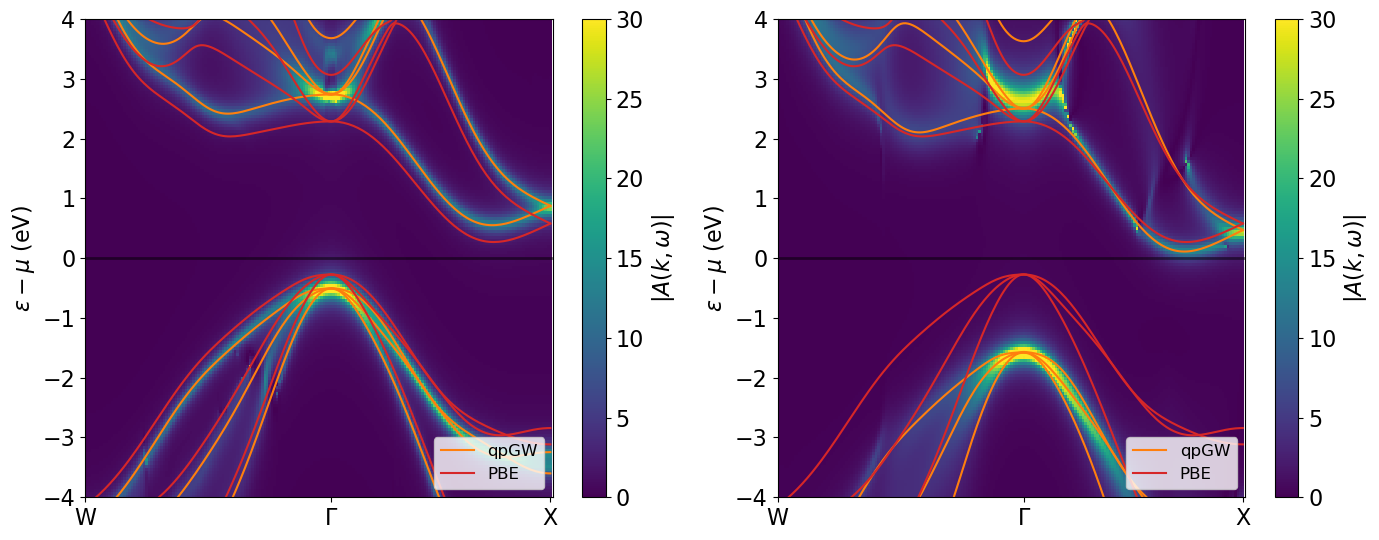

In [7]:
# First iteration, corresponding to G0W0
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), dpi=100)

for i in range(2):
    iteration = 1 if i == 0 else -1
    # Step 1: Plot spectral function A(k, ω)
    coqui.post_proc.spectral_plot(ax[i], coqui_h5="si.gw.mbpt.h5", iteration=iteration, calc_type="mbpt", verbal=False)
    coqui.post_proc.band_plot(ax[i], coqui_h5="si.gw.mbpt.h5", iteration=iteration, verbal=False,
                              color="tab:orange", label="qpGW")
    # Step 2: Overlay PBE bands
    coqui.post_proc.band_plot(ax[i], coqui_h5="si.evgw.mbpt.h5", iteration=0, verbal=False,
                              color="tab:red", label="PBE")
    ax[i].axhline(y=0.0, color="black", linestyle="-", linewidth=2.0, alpha=0.5)

    ax[i].set_ylim(-4, 4)
    ax[i].legend(loc=4, fontsize=12)
plt.tight_layout()
plt.show()

#### 🔹 Final remarks

This notebook introduced the core GW workflow in CoQuí: building a THC Coulomb Hamiltonian, running two complementary GW flavors, and post-processing the resulting quasiparticle bands and spectral functions. The main conceptual contrast is that evGW is a quasiparticle-focused approximation that is convenient for band-structure analysis, whereas full-frequency scGW retains the full dynamical self-energy and is more compatible with strong correlations. 

At the same time, this notebook is only a quickstart. The examples here use intentionally small numerical settings so that the workflow remains interactive. For quantitative calculations, several additional checks are essential:

1. **Convergence with respect to the number of bands** included in the GW calculation.

2. **Convergence with respect to the k-point mesh**, which affect both the quantitative GW results, and the quality of interpolation in the post-processing stage.